In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df=pd.read_csv('/content/data_for_lr.csv')

In [36]:
print(df.head())
print(df.info())
print(df.describe())

      x          y
0  24.0  21.549452
1  50.0  47.464463
2  15.0  17.218656
3  38.0  36.586398
4  87.0  87.288984
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB
None
                 x           y
count   700.000000  699.000000
mean     54.985939   49.939869
std     134.681703   29.109217
min       0.000000   -3.839981
25%      25.000000   24.929968
50%      49.000000   48.973020
75%      75.000000   74.929911
max    3530.157369  108.871618


In [44]:
df.isnull().sum()

,0
x,0
y,1


In [45]:
df=df.dropna()

In [46]:
df.isnull().sum()

,0
x,0
y,0


<Axes: xlabel='x', ylabel='y'>

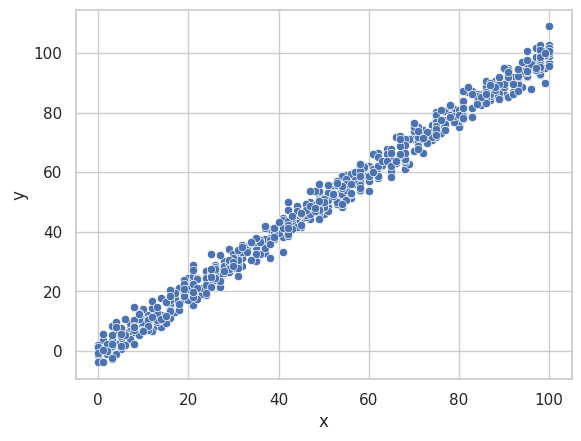

In [47]:
sns.set(style='whitegrid')
sns.scatterplot(x="x",y="y",data=df)

In [48]:
# Train Test Data

In [67]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.x,df.y,test_size=0.2,random_state=42)

In [68]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(559,) (140,) (559,) (140,)


In [69]:
# Reshape the Data

x_train=x_train.to_numpy().reshape(-1,1)
x_test=x_test.to_numpy().reshape(-1,1)
x_test.shape,x_train.shape

((140, 1), (559, 1))

In [70]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [73]:
predictions=lr.predict(x_test)
lr.score(x_test,y_test)

0.9910998765243975

In [76]:
# Evaluate Model
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [80]:
mae=mean_absolute_error(y_test,predictions)
mse=mean_squared_error(y_test,predictions)
rmse=root_mean_squared_error(y_test,predictions)
r2=r2_score(y_test,predictions)

In [84]:
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R²): {r2}')

Mean Absolute Error (MAE): 2.2020818674091127
Mean Squared Error (MSE): 7.752986666319193
Root Mean Squared Error (RMSE): 2.7844185508502837
R-squared (R²): 0.9910998765243975


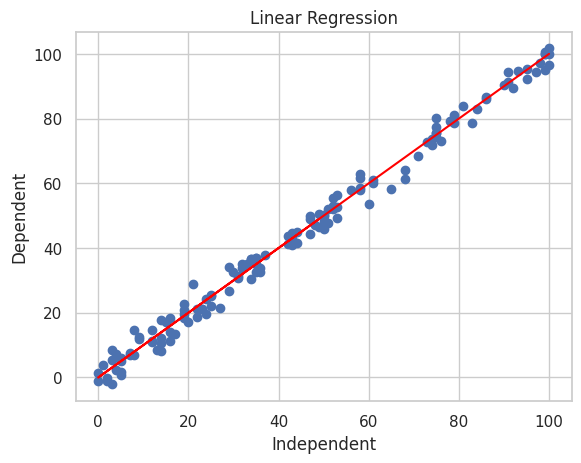

In [92]:
# visualize

plt.scatter(x_test , y_test)
plt.plot(x_test,predictions,color='red')
plt.xlabel('Independent') , plt.ylabel('Dependent')
plt.title('Linear Regression')
plt.show()